In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amineipad/cic-iomt-dataset-2024/train_iomt.csv
/kaggle/input/datasets/amineipad/cic-iomt-dataset-2024/test_iomt.csv
/kaggle/input/datasets/amineipad/cic-iomt-dataset-2024/.virtual_documents/__notebook_source__.ipynb


In [2]:
# step 1
import pandas as pd

train = pd.read_csv("/kaggle/input/datasets/amineipad/cic-iomt-dataset-2024/train_iomt.csv")
test = pd.read_csv("/kaggle/input/datasets/amineipad/cic-iomt-dataset-2024/test_iomt.csv")

In [3]:
# step 2
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

print("\nColumns:")
print(train.columns.tolist())

print("\nData Types:")
print(train.dtypes)

Train Shape: (7160831, 46)
Test Shape: (1614182, 46)

Columns:
['Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']

Data Types:
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate              float64
Drate                int64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count          float64
syn_count          float64
fin_count  

In [4]:
# step 3
print(train["label"].value_counts())

label
DDoS UDP              1635956
DDoS ICMP             1537476
DDoS TCP               804465
DDoS SYN               801962
DoS UDP                566950
DoS SYN                441903
DoS ICMP               416292
DoS TCP                380384
benign                 192732
DoS Connect Flood      185809
Port Scan               83981
DoS Publish Flood       44376
DDoS Publish Flood      27623
OS Scan                 16832
ARP Spoofing            16047
Malformed Data           5130
Recon VulScan            2173
Ping Sweep                740
Name: count, dtype: int64


In [5]:
# step 4
print(train["label"].value_counts(normalize=True) * 100)

label
DDoS UDP              22.845896
DDoS ICMP             21.470637
DDoS TCP              11.234241
DDoS SYN              11.199287
DoS UDP                7.917377
DoS SYN                6.171113
DoS ICMP               5.813459
DoS TCP                5.312009
benign                 2.691475
DoS Connect Flood      2.594797
Port Scan              1.172783
DoS Publish Flood      0.619705
DDoS Publish Flood     0.385751
OS Scan                0.235057
ARP Spoofing           0.224094
Malformed Data         0.071640
Recon VulScan          0.030346
Ping Sweep             0.010334
Name: proportion, dtype: float64


In [6]:
# step 5
print(train["label"].unique())

['DDoS UDP' 'DDoS ICMP' 'DoS SYN' 'DoS Connect Flood' 'DDoS Publish Flood'
 'DDoS SYN' 'DDoS TCP' 'DoS Publish Flood' 'DoS TCP' 'DoS UDP' 'DoS ICMP'
 'benign' 'OS Scan' 'Ping Sweep' 'Recon VulScan' 'Port Scan'
 'Malformed Data' 'ARP Spoofing']


In [7]:
# step 6
print(train["Protocol Type"].describe())

count    7.160831e+06
mean     8.043003e+00
std      6.292264e+00
min      0.000000e+00
25%      1.160156e+00
50%      6.000000e+00
75%      1.700000e+01
max      1.700000e+01
Name: Protocol Type, dtype: float64


In [8]:
# step 7
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Header_Length,7160831.0,2.958836e+04,2.762618e+05,0.000000,5.400000e+01,1.080000e+02,1.958050e+04,9.895636e+06
Protocol Type,7160831.0,8.043003e+00,6.292264e+00,0.000000,1.160156e+00,6.000000e+00,1.700000e+01,1.700000e+01
Duration,7160831.0,6.474657e+01,8.405244e+00,0.000000,6.400000e+01,6.400000e+01,6.400000e+01,2.550000e+02
Rate,7160831.0,1.523202e+04,3.950968e+04,0.000000,6.685014e+00,1.452887e+02,1.914681e+04,2.097152e+06
Srate,7160831.0,1.523202e+04,3.950968e+04,0.000000,6.685014e+00,1.452887e+02,1.914681e+04,2.097152e+06
Drate,7160831.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
fin_flag_number,7160831.0,5.079653e-03,3.411234e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
syn_flag_number,7160831.0,1.587621e-01,3.388265e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
rst_flag_number,7160831.0,3.862118e-02,1.370999e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
psh_flag_number,7160831.0,2.240627e-02,9.713046e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [9]:
# step 8
print(train.isnull().sum())

Header_Length      0
Protocol Type      0
Duration           0
Rate               0
Srate              0
Drate              0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
psh_flag_number    0
ack_flag_number    0
ece_flag_number    0
cwr_flag_number    0
ack_count          0
syn_count          0
fin_count          0
rst_count          0
HTTP               0
HTTPS              0
DNS                0
Telnet             0
SMTP               0
SSH                0
IRC                0
TCP                0
UDP                0
DHCP               0
ARP                0
ICMP               0
IGMP               0
IPv                0
LLC                0
Tot sum            0
Min                0
Max                0
AVG                0
Std                0
Tot size           0
IAT                0
Number             0
Magnitue           0
Radius             0
Covariance         0
Variance           0
Weight             0
label              0
dtype: int64


In [11]:
# step 9
protocol_cols = ["TCP", "UDP", "HTTP", "HTTPS", "DNS", "ICMP", "ARP", "DHCP", "SSH", "SMTP", "Telnet", "IRC", "IGMP"]

print(train[protocol_cols].sum().sort_values(ascending=False))

TCP       2.981410e+06
UDP       2.220766e+06
ICMP      1.953115e+06
HTTPS     4.475046e+04
ARP       5.580078e+03
HTTP      4.338930e+03
DNS       1.124080e+03
SSH       1.058337e+02
Telnet    9.779531e+01
SMTP      9.779316e+01
IRC       9.758637e+01
IGMP      3.310693e+01
DHCP      2.749968e+01
dtype: float64


In [12]:
# step 10
(train.isnull().sum() / len(train) * 100)

Header_Length      0.0
Protocol Type      0.0
Duration           0.0
Rate               0.0
Srate              0.0
Drate              0.0
fin_flag_number    0.0
syn_flag_number    0.0
rst_flag_number    0.0
psh_flag_number    0.0
ack_flag_number    0.0
ece_flag_number    0.0
cwr_flag_number    0.0
ack_count          0.0
syn_count          0.0
fin_count          0.0
rst_count          0.0
HTTP               0.0
HTTPS              0.0
DNS                0.0
Telnet             0.0
SMTP               0.0
SSH                0.0
IRC                0.0
TCP                0.0
UDP                0.0
DHCP               0.0
ARP                0.0
ICMP               0.0
IGMP               0.0
IPv                0.0
LLC                0.0
Tot sum            0.0
Min                0.0
Max                0.0
AVG                0.0
Std                0.0
Tot size           0.0
IAT                0.0
Number             0.0
Magnitue           0.0
Radius             0.0
Covariance         0.0
Variance   

In [13]:
# step 11
print("Train Classes:", sorted(train["label"].unique()))
print("Test Classes :", sorted(test["label"].unique()))

Train Classes: ['ARP Spoofing', 'DDoS ICMP', 'DDoS Publish Flood', 'DDoS SYN', 'DDoS TCP', 'DDoS UDP', 'DoS Connect Flood', 'DoS ICMP', 'DoS Publish Flood', 'DoS SYN', 'DoS TCP', 'DoS UDP', 'Malformed Data', 'OS Scan', 'Ping Sweep', 'Port Scan', 'Recon VulScan', 'benign']
Test Classes : ['ARP Spoofing', 'DDoS ICMP', 'DDoS Publish Flood', 'DDoS SYN', 'DDoS TCP', 'DDoS UDP', 'DoS Connect Flood', 'DoS ICMP', 'DoS Publish Flood', 'DoS SYN', 'DoS TCP', 'DoS UDP', 'Malformed Data', 'OS Scan', 'Ping Sweep', 'Port Scan', 'Recon VulScan', 'benign']


In [14]:
#step 12
total_records = len(train) + len(test)

print("Training Samples :", len(train))
print("Testing Samples  :", len(test))
print("Total Samples    :", total_records)
print("Features         :", train.shape[1]-1)
print("Target Column    :", "label")
print("Attack Classes   :", train["label"].nunique())

Training Samples : 7160831
Testing Samples  : 1614182
Total Samples    : 8775013
Features         : 45
Target Column    : label
Attack Classes   : 18


In [15]:
# step 13
attack_classes = pd.DataFrame({
    "Attack Category": train["label"].value_counts().index,
    "Samples": train["label"].value_counts().values,
    "Percentage": (train["label"].value_counts(normalize=True) * 100).round(2).values
})

attack_classes

,Attack Category,Samples,Percentage
0,DDoS UDP,1635956,22.85
1,DDoS ICMP,1537476,21.47
2,DDoS TCP,804465,11.23
3,DDoS SYN,801962,11.20
4,DoS UDP,566950,7.92
5,DoS SYN,441903,6.17
6,DoS ICMP,416292,5.81
7,DoS TCP,380384,5.31
8,benign,192732,2.69
9,DoS Connect Flood,185809,2.59


In [16]:
# step 14
attack_classes.to_csv("Attack_Class_Distribution.csv", index=False)

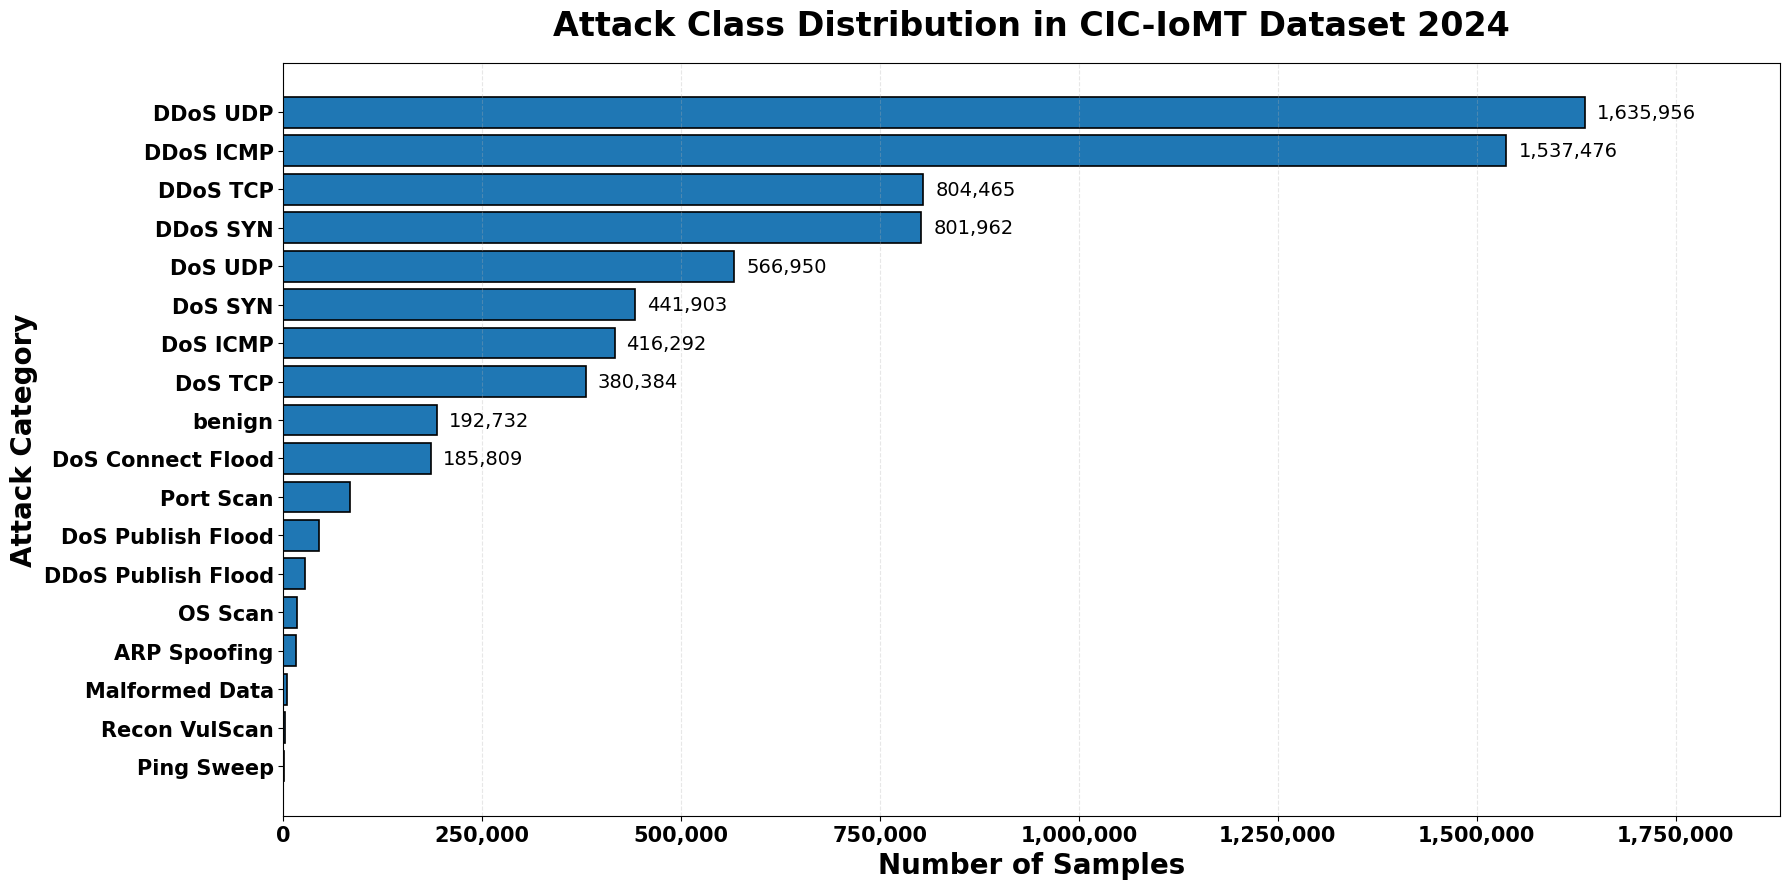

In [17]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

attack_classes = train["label"].value_counts()

fig, ax = plt.subplots(figsize=(18,9))

bars = ax.barh(
    attack_classes.index,
    attack_classes.values,
    edgecolor="black",
    linewidth=1.2
)

ax.set_title(
    "Attack Class Distribution in CIC-IoMT Dataset 2024",
    fontsize=24,  # Title thora aur prominent kiya hai
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Number of Samples",
    fontsize=20,  # X-axis label size increase kiya
    fontweight="bold"
)

ax.set_ylabel(
    "Attack Category",
    fontsize=20,  # Y-axis label size increase kiya
    fontweight="bold"
)

# Tick labels ka size 13 se 15 kar diya taake categories clear parhi jayen
plt.xticks(fontsize=15, fontweight="bold")
plt.yticks(fontsize=15, fontweight="bold")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ",")))
ax.grid(axis="x", linestyle="--", alpha=0.3)

max_value = attack_classes.max()
ax.set_xlim(0, max_value * 1.15) 

for bar in bars:
    width = bar.get_width()      
    if width > 100000:           
        ax.text(
            width + 15000,                   
            bar.get_y() + bar.get_height()/2, 
            f"{int(width):,}",
            ha="left",                       
            va="center",                     
            fontsize=14,           # Yahan 10 se 14 kar diya gaya hai
            fontweight="normal"    # Bold khatam kar diya taake numbers aapas mein na milen
        )

ax.invert_yaxis()
plt.tight_layout()

plt.savefig("Attack_Class_Distribution_Horizontal.png", dpi=300, bbox_inches="tight")
plt.savefig("Attack_Class_Distribution_Horizontal.pdf", bbox_inches="tight")
plt.show()

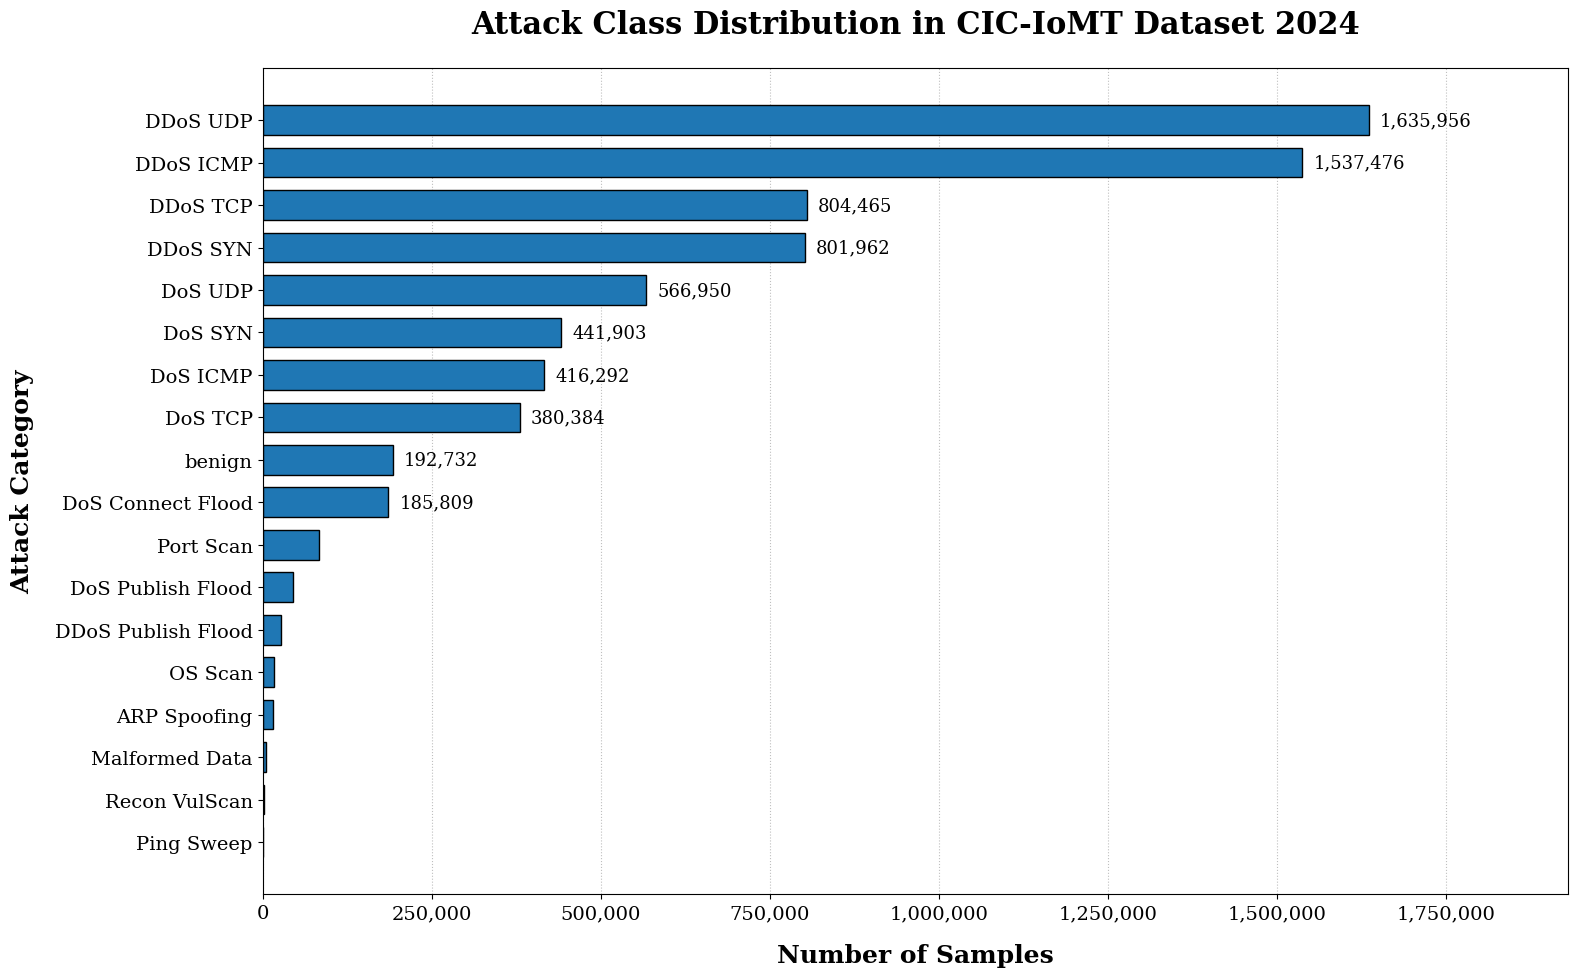

In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Q1 Journal Styling: Setting font to Serif
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.titlesize": 22,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

attack_classes = train["label"].value_counts()

# Figure size ko thora aur balanced kiya hai
fig, ax = plt.subplots(figsize=(16, 10))

# Bars ki height/thickness kam ki hai aur professional color add kiya hai
bars = ax.barh(
    attack_classes.index,
    attack_classes.values,
    edgecolor="black",
    linewidth=1.0,
    height=0.7,         
    color="#1f77b4"     
)

ax.set_title(
    "Attack Class Distribution in CIC-IoMT Dataset 2024",
    fontweight="bold",
    pad=25
)

ax.set_xlabel("Number of Samples", fontweight="bold", labelpad=15)
ax.set_ylabel("Attack Category", fontweight="bold", labelpad=15)

# Formatting X-axis with commas
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ",")))

# Subtle grid lines only on X-axis
ax.grid(axis="x", linestyle=":", color="gray", alpha=0.5)
ax.set_axisbelow(True) # Grid lines bars ke peechay rakhne ke liye

# Outer limits ko extend karna
max_value = attack_classes.max()
ax.set_xlim(0, max_value * 1.18) # Thora mazeed margin diya hai

# Text Labels on Bars
for bar in bars:
    width = bar.get_width()      
    if width > 100000:           
        ax.text(
            width + (max_value * 0.01), # Spacing ko dynamically adjust kiya hai                  
            bar.get_y() + bar.get_height()/2, 
            f"{int(width):,}",
            ha="left",                       
            va="center",                     
            fontsize=13
        )

ax.invert_yaxis()
plt.tight_layout()

# Saving high-resolution files
plt.savefig("Attack_Class_Distribution_Q1.png", dpi=600, bbox_inches="tight")
plt.savefig("Attack_Class_Distribution_Q1.pdf", bbox_inches="tight")

plt.show()

In [19]:
print("Training Duplicates:", train.duplicated().sum())
print("Testing Duplicates :", test.duplicated().sum())

Training Duplicates: 2645753
Testing Duplicates : 721916


In [20]:
print(train["label"].dtype)
print(train["label"].head())

object
0    DDoS UDP
1    DDoS UDP
2    DDoS UDP
3    DDoS UDP
4    DDoS UDP
Name: label, dtype: object


In [21]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train["label"] = label_encoder.fit_transform(train["label"])
test["label"] = label_encoder.transform(test["label"])

print(label_encoder.classes_)
print(train["label"].head())

['ARP Spoofing' 'DDoS ICMP' 'DDoS Publish Flood' 'DDoS SYN' 'DDoS TCP'
 'DDoS UDP' 'DoS Connect Flood' 'DoS ICMP' 'DoS Publish Flood' 'DoS SYN'
 'DoS TCP' 'DoS UDP' 'Malformed Data' 'OS Scan' 'Ping Sweep' 'Port Scan'
 'Recon VulScan' 'benign']
0    5
1    5
2    5
3    5
4    5
Name: label, dtype: int64


In [22]:
X_train = train.drop("label", axis=1)
y_train = train["label"]

X_test = test.drop("label", axis=1)
y_test = test["label"]

print(X_train.shape)
print(y_train.shape)

(7160831, 45)
(7160831,)


In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

(7160831, 45)


In [24]:
# Check number of unique values for every feature
unique_counts = X_train.nunique().sort_values()

print(unique_counts)

Drate                    1
cwr_flag_number          6
Telnet                   6
SMTP                     7
IRC                      7
ece_flag_number          8
IGMP                    13
SSH                     14
HTTP                    33
DHCP                    33
DNS                     62
LLC                     72
ARP                     72
IPv                     72
Number                  86
Weight                  92
ICMP                   227
fin_flag_number        229
TCP                    253
HTTPS                  257
UDP                    282
psh_flag_number        428
rst_flag_number        501
syn_flag_number        525
ack_count              563
ack_flag_number        619
Variance               772
syn_count              986
Protocol Type         1441
fin_count             2605
Magnitue              2637
Duration              2684
Min                   5117
Tot size              5275
Max                   5287
AVG                   5291
Tot sum               6502
r

In [25]:
# Features having only one unique value
constant_features = unique_counts[unique_counts <= 1]

print("Constant Features:")
print(constant_features)

Constant Features:
Drate    1
dtype: int64


In [26]:
# Variance of each feature
feature_variance = X_train.var().sort_values()

print("Features with lowest variance:")
print(feature_variance.head(15))

Features with lowest variance:
Drate              0.000000e+00
cwr_flag_number    1.149845e-07
ece_flag_number    1.977533e-07
Telnet             9.040141e-07
IRC                9.040349e-07
SMTP               9.040586e-07
DHCP               1.178941e-06
SSH                1.387475e-06
IGMP               1.550743e-06
DNS                2.962176e-05
ARP                3.856355e-04
LLC                3.856875e-04
IPv                3.856875e-04
HTTP               5.403140e-04
fin_flag_number    1.163652e-03
dtype: float64


In [27]:
print("Train Drate unique values:")
print(train["Drate"].unique())

print("\nTest Drate unique values:")
print(test["Drate"].unique())

print("\nTrain Drate variance:", train["Drate"].var())
print("Test Drate variance :", test["Drate"].var())

Train Drate unique values:
[0]

Test Drate unique values:
[0]

Train Drate variance: 0.0
Test Drate variance : 0.0


In [29]:
# Use a representative sample for correlation analysis
X_sample = X_train.sample(
    n=min(100000, len(X_train)),
    random_state=42
)

# Correlation matrix
corr_matrix = X_sample.corr().abs()

# Find highly correlated feature pairs
threshold = 0.95

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] >= threshold:
            high_corr_pairs.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                )
            )

print("Highly correlated feature pairs (|r| >= 0.95):")

for pair in high_corr_pairs:
    print(pair)

Highly correlated feature pairs (|r| >= 0.95):
('Rate', 'Srate', np.float64(1.0))
('ece_flag_number', 'cwr_flag_number', np.float64(0.9967236513420107))
('ARP', 'IPv', np.float64(0.9999997282807417))
('ARP', 'LLC', np.float64(0.9999997282807417))
('IPv', 'LLC', np.float64(1.0))
('AVG', 'Tot size', np.float64(0.9825504590208909))
('AVG', 'Magnitue', np.float64(0.9750821183195199))
('Std', 'Radius', np.float64(0.9999738385950327))
('Std', 'Covariance', np.float64(0.9597281888475949))
('Tot size', 'Magnitue', np.float64(0.9587365131391287))
('IAT', 'Number', np.float64(0.998141277382914))
('IAT', 'Weight', np.float64(0.9989035414895453))
('Number', 'Weight', np.float64(0.9998009932287568))
('Radius', 'Covariance', np.float64(0.9597287780027436))


In [30]:
# Remove constant feature
X_train_fs = X_train.drop(columns=["Drate"])
X_test_fs = X_test.drop(columns=["Drate"])

print("Original features :", X_train.shape[1])
print("After feature selection :", X_train_fs.shape[1])

print("\nRemaining features:")
print(X_train_fs.columns.tolist())

Original features : 45
After feature selection : 44

Remaining features:
['Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']


In [31]:
from sklearn.ensemble import RandomForestClassifier

# Representative sample
sample_size = 100000

X_fs_sample = X_train_fs.sample(
    n=min(sample_size, len(X_train_fs)),
    random_state=42
)

y_fs_sample = y_train.loc[X_fs_sample.index]

print("Sample shape:", X_fs_sample.shape)
print("Target shape:", y_fs_sample.shape)

Sample shape: (100000, 44)
Target shape: (100000,)


In [32]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_fs_sample, y_fs_sample)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X_fs_sample.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance.to_string(index=False))

        Feature  Importance
            IAT    0.230661
           Rate    0.058113
          Srate    0.053431
      fin_count    0.047469
  Header_Length    0.043304
       Tot size    0.040611
      rst_count    0.038276
       Magnitue    0.037623
      syn_count    0.036860
            AVG    0.036401
            Min    0.035215
            Max    0.031586
syn_flag_number    0.026683
        Tot sum    0.021772
  Protocol Type    0.020802
       Duration    0.019741
      ack_count    0.019199
            TCP    0.017215
            Std    0.015175
         Weight    0.015093
ack_flag_number    0.015007
         Number    0.013984
psh_flag_number    0.013825
            UDP    0.013490
rst_flag_number    0.013422
     Covariance    0.012184
          HTTPS    0.011342
         Radius    0.011089
       Variance    0.010780
            ARP    0.010093
           ICMP    0.008703
fin_flag_number    0.007985
            IPv    0.006879
            LLC    0.005175
           HTTP    0

In [34]:
feature_importance["Cumulative Importance"] = (
    feature_importance["Importance"].cumsum()
)

print(feature_importance.to_string(index=False))

        Feature  Importance  Cumulative Importance
            IAT    0.230661               0.230661
           Rate    0.058113               0.288774
          Srate    0.053431               0.342206
      fin_count    0.047469               0.389675
  Header_Length    0.043304               0.432979
       Tot size    0.040611               0.473589
      rst_count    0.038276               0.511865
       Magnitue    0.037623               0.549488
      syn_count    0.036860               0.586349
            AVG    0.036401               0.622749
            Min    0.035215               0.657964
            Max    0.031586               0.689550
syn_flag_number    0.026683               0.716233
        Tot sum    0.021772               0.738004
  Protocol Type    0.020802               0.758806
       Duration    0.019741               0.778547
      ack_count    0.019199               0.797746
            TCP    0.017215               0.814961
            Std    0.015175    

In [35]:
thresholds = [0.90, 0.95, 0.99]

for threshold in thresholds:
    n_features = (
        feature_importance["Cumulative Importance"] <= threshold
    ).sum()

    print(
        f"Features needed for {threshold*100:.0f}% cumulative importance:",
        n_features
    )

Features needed for 90% cumulative importance: 23
Features needed for 95% cumulative importance: 28
Features needed for 99% cumulative importance: 32


In [36]:
selected_features = feature_importance[
    feature_importance["Cumulative Importance"] <= 0.99
]["Feature"].tolist()

In [37]:
selected_features = feature_importance[
    "Feature"
].tolist()[:29]

print("Selected Features:", len(selected_features))
print(selected_features)

Selected Features: 29
['IAT', 'Rate', 'Srate', 'fin_count', 'Header_Length', 'Tot size', 'rst_count', 'Magnitue', 'syn_count', 'AVG', 'Min', 'Max', 'syn_flag_number', 'Tot sum', 'Protocol Type', 'Duration', 'ack_count', 'TCP', 'Std', 'Weight', 'ack_flag_number', 'Number', 'psh_flag_number', 'UDP', 'rst_flag_number', 'Covariance', 'HTTPS', 'Radius', 'Variance']


In [38]:
X_train_selected = X_train_fs[selected_features]
X_test_selected = X_test_fs[selected_features]

print("Original features:", X_train_fs.shape[1])
print("Selected features:", X_train_selected.shape[1])

Original features: 44
Selected features: 29


In [39]:
print("Before duplicate removal:")
print("Train:", X_train_selected.shape)
print("Test :", X_test_selected.shape)

train_dup_mask = train.duplicated()
test_dup_mask = test.duplicated()

print("Training duplicates:", train_dup_mask.sum())
print("Testing duplicates :", test_dup_mask.sum())

Before duplicate removal:
Train: (7160831, 29)
Test : (1614182, 29)
Training duplicates: 2645753
Testing duplicates : 721916


In [40]:
duplicate_rows = train[train.duplicated(keep=False)]

print("Duplicate rows:", len(duplicate_rows))

print(
    duplicate_rows.groupby(
        train.loc[duplicate_rows.index, "label"]
    ).size().sort_values(ascending=False).head(20)
)

Duplicate rows: 2841106
label
1     1394119
4      611214
7      305240
3      237617
10     170724
9      104426
15      14474
13       2949
16        158
14         81
0          58
11         46
dtype: int64


In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

print("Training minimum:", X_train_scaled.min())
print("Training maximum:", X_train_scaled.max())

Scaled training shape: (7160831, 29)
Scaled testing shape : (1614182, 29)
Training minimum: 0.0
Training maximum: 1.0


In [42]:
print("Training class distribution:")
print(train["label"].value_counts().sort_index())

print("\nTraining class percentages:")
print(
    (train["label"].value_counts(normalize=True).sort_index() * 100)
    .round(4)
)

Training class distribution:
label
0       16047
1     1537476
2       27623
3      801962
4      804465
5     1635956
6      185809
7      416292
8       44376
9      441903
10     380384
11     566950
12       5130
13      16832
14        740
15      83981
16       2173
17     192732
Name: count, dtype: int64

Training class percentages:
label
0      0.2241
1     21.4706
2      0.3858
3     11.1993
4     11.2342
5     22.8459
6      2.5948
7      5.8135
8      0.6197
9      6.1711
10     5.3120
11     7.9174
12     0.0716
13     0.2351
14     0.0103
15     1.1728
16     0.0303
17     2.6915
Name: proportion, dtype: float64


In [43]:
print("Testing class distribution:")
print(test["label"].value_counts().sort_index())

print("\nTesting class percentages:")
print(
    (test["label"].value_counts(normalize=True).sort_index() * 100)
    .round(4)
)

Testing class distribution:
label
0       1744
1     349699
2       8416
3     172397
4     182598
5     362070
6      45047
7      98432
8       8505
9      98595
10     82096
11    137553
12      1747
13      3834
14       186
15     22622
16      1034
17     37607
Name: count, dtype: int64

Testing class percentages:
label
0      0.1080
1     21.6642
2      0.5214
3     10.6801
4     11.3121
5     22.4306
6      2.7907
7      6.0979
8      0.5269
9      6.1080
10     5.0859
11     8.5215
12     0.1082
13     0.2375
14     0.0115
15     1.4015
16     0.0641
17     2.3298
Name: proportion, dtype: float64


In [44]:
# ============================================
# DUPLICATE REMOVAL
# ============================================
print("Before duplicate removal:")
print("Train:", train.shape)
print("Test :", test.shape)

train.drop_duplicates(inplace=True)
test.drop_duplicates(inplace=True)

print("\nAfter duplicate removal:")
print("Train:", train.shape)
print("Test :", test.shape)

print("\nDuplicates remaining:")
print("Train:", train.duplicated().sum())
print("Test :", test.duplicated().sum())

Before duplicate removal:
Train: (7160831, 46)
Test : (1614182, 46)

After duplicate removal:
Train: (4515078, 46)
Test : (892266, 46)

Duplicates remaining:
Train: 0
Test : 0


In [47]:
# ============================================
# TRAIN-TEST OVERLAP CHECK
# ============================================

feature_cols = selected_features

# یہاں train_clean اور test_clean کی جگہ صرف train اور test کر دیا گیا ہے
train_features = train[feature_cols]
test_features = test[feature_cols]

# Find exact feature rows appearing in both datasets
train_feature_set = set(map(tuple, train_features.to_numpy()))

overlap_mask = test_features.apply(
    lambda row: tuple(row) in train_feature_set,
    axis=1
)

print("Exact feature-row overlap:", overlap_mask.sum())

Exact feature-row overlap: 465


In [49]:
# ============================================
# CHECK LABELS & REMOVE OVERLAPPING RECORDS
# ============================================

# test_clean کی جگہ صرف test کر دیا ہے
overlap_test = test.loc[overlap_mask].copy()

print("Overlapping test records:", len(overlap_test))

if len(overlap_test) > 0:
    print("\nLabels of overlapping test records:")
    print(overlap_test["label"].value_counts().sort_index())

# ان 465 روز کو ٹیسٹ سیٹ سے ہمیشہ کے لیے ریموو کرنے کا کوڈ
test = test.loc[~overlap_mask].reset_index(drop=True)

print("\nOverlap removed successfully!")
print("New Test Set Shape:", test.shape)

Overlapping test records: 465

Labels of overlapping test records:
label
1      21
3      14
4      27
7       8
9       1
10      9
15    385
Name: count, dtype: int64

Overlap removed successfully!
New Test Set Shape: (891801, 46)


In [50]:
# Check new shape of the datasets
print("Cleaned Train Shape:", train.shape)
print("Cleaned Test Shape:", test.shape)

# Check the new class distribution in Train Set
print("\nClass Distribution in Train Set:")
class_counts = train["label"].value_counts()
print(class_counts)

# Check percentage of each class
print("\nClass Percentages:")
print((class_counts / len(train)) * 100)

Cleaned Train Shape: (4515078, 46)
Cleaned Test Shape: (891801, 46)

Class Distribution in Train Set:
label
5     1635956
3      577649
11     566921
9      347035
4      248267
10     221180
1      210257
17     192732
6      185809
7      145313
15      73885
8       44376
2       27623
0       16010
13      14214
12       5130
16       2032
14        689
Name: count, dtype: int64

Class Percentages:
label
5     36.233172
3     12.793777
11    12.556173
9      7.686135
4      5.498620
10     4.898697
1      4.656774
17     4.268631
6      4.115300
7      3.218394
15     1.636406
8      0.982840
2      0.611795
0      0.354590
13     0.314812
12     0.113619
16     0.045005
14     0.015260
Name: count, dtype: float64


In [51]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.sort(train["label"].unique())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train["label"]
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
for cls, weight in class_weight_dict.items():
    print(f"Class {cls}: {weight:.4f}")

Class weights:
Class 0: 15.6676
Class 1: 1.1930
Class 2: 9.0808
Class 3: 0.4342
Class 4: 1.0104
Class 5: 0.1533
Class 6: 1.3500
Class 7: 1.7262
Class 8: 5.6526
Class 9: 0.7228
Class 10: 1.1341
Class 11: 0.4425
Class 12: 48.8962
Class 13: 17.6472
Class 14: 364.0605
Class 15: 3.3950
Class 16: 123.4437
Class 17: 1.3015
